# Full pipeline for preprosessing, labeling and segmenting a test file set, for 6 sensors

The M.Sc. spring 2026 edition, though this is heavily based on the code from the specialization project conducted in the fall of 2026, which again is heavily derived off of Maria's masters thesis: https://nva.sikt.no/registration/019aaa5d3e02-1f393658-c1a9-4f74-96a3-c428dc10c170

### Imports

In [1]:
from pre_processing.labeling import detect_spikes, init_label, plot_signal_peaks, extract_activity_windows, apply_corrected_labels, extract_pressure_data, remove_idle, sort_push_pull
from pre_processing.fiks_time_muse import make_df, check_samples, fix_time_muse_hz
from pre_processing.clean_mitch_timestamps import remove_end_duplicates, add_ReconstructedTime
from pre_processing.filter_sensor_data import median_filter_medfilt
from pre_processing.segment_repetition_vol2 import plot_activity_accelerations_peaks_and_magnitude, get_start_stop_times_from_peaks, assign_rep_ids

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Define path to raw sensor files and output directory (same dir as test files is convention)

First, define where data files exist by modifying base_dir and participant_dir_name. Use standardized naming to make file retrieval easier! 

In [2]:
base_dir = Path(r"C:\Users\Bruker\Data_msc26_prelim")
participant_dir_name = "prelim_1"

data_dir = base_dir / participant_dir_name

Assuming a certain naming structure and sensor placement, run the cell below to get the data files from the participant defined in participant_dir_name.

In [3]:
# Define path to arm sensor file (raw data)
raw_rarm = data_dir / "Muse_E2511_RED-ARM_RIGHT.txt"
raw_larm = data_dir / "Muse_E2511_GREY-ARM_LEFT.txt"
raw_lb = data_dir / "muse_v3_3-LB.txt"
raw_ub = data_dir / "muse_v3-UB.txt"
raw_lsole = data_dir / "mitch_B0308-LEFT.txt"
raw_rsole = data_dir / "mitch_B0510-RIGHT.txt"

output_dir = data_dir # optionally set output dir to something else, but output being the same directory as the raw sensor files has been practice up until now :)

### OUTDATED A sanity check, compare new raw data to Maria's data
At the early stage of my data collection, ensure that i have done it correctly, i.e. the sensors work the way they should and the raw time series look somewhat similar.

In [ ]:
# Maria testfiles:
maria_arm = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\Muse_E2511_RED-arm.txt"
maria_back = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\Muse_E2511_GREY-back.txt"
maria_left = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\mitch_B0510-new_left_small.txt"
maria_right = r"C:\Users\Bruker\Master25_code\Master25\Data\sensor_test_files_master_maria\test_5\mitch_B0308-old_right_small.txt"

In [ ]:
# Muse axl comparison
muse_dfs_j = make_df(muse_file_1=raw_arm_path, muse_file_2=raw_back_path)
muse_dfs_m = make_df(muse_file_1=maria_arm, muse_file_2=maria_back)

AX_COLS = ["Axl.X", "Axl.Y", "Axl.Z"]
MAG_COLS = ["Mag.X", "Mag.Y", "Mag.Z"]

x_j_arm = muse_dfs_j[0]["Timestamp"]
x_m_arm = muse_dfs_m[0]["Timestamp"]

x_j_back = muse_dfs_j[1]["Timestamp"]
x_m_back = muse_dfs_m[1]["Timestamp"]
# two subplots (stacked). use (1,2) for side-by-side
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=False, sharey=True)

print("DEBUG LENGTH PRINTS")
print(len(x_j_arm))
print(len(x_j_back))

for col in AX_COLS:
    axes[0].plot(x_j_arm, muse_dfs_j[0][col])
axes[0].set_title("Johanne — Accelerometer X, Y, Z arm")
axes[0].set_xlabel("Timestamp")
#axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

for col in AX_COLS:
    axes[2].plot(x_j_back, muse_dfs_j[1][col], label=col)
axes[2].set_title("Johanne — Magnetometer X, Y, Z back")
axes[2].set_xlabel("Timestamp")
#axes[0].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-10000, 10000)
axes[2].legend(loc='upper right')


for col in AX_COLS:
    axes[1].plot(x_m_arm, muse_dfs_m[0][col])
axes[1].set_title("Maria test 5 — Accelerometer X, Y, Z arm")
axes[1].set_xlabel("Timestamp")
#axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

for col in AX_COLS:
    axes[3].plot(x_m_back, muse_dfs_m[1][col], label=col)
axes[3].set_title("Maria test 5 — Magnetometer X, Y, Z back")
axes[3].set_xlabel("Timestamp")
#axes[1].legend(loc='upper right')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(-10000, 10000)
axes[3].legend(loc='upper right')

#plt.tight_layout()
plt.show()


In [ ]:
# MITCH PRESSURE COMPARISONS
# convert mitch .txt files to df list
left_df_j = pd.read_csv(raw_left_path, delimiter="\t", skiprows=8, decimal=",")
right_df_j = pd.read_csv(raw_right_path, delimiter="\t", skiprows=8, decimal=",")

left_df_m = pd.read_csv(maria_left, delimiter="\t", skiprows=8, decimal=",")
right_df_m = pd.read_csv(maria_right, delimiter="\t", skiprows=8, decimal=",")

list_j = [left_df_j, right_df_j, None, None]
list_m = [left_df_m, right_df_m, None, None]

print(left_df_j.min(), left_df_m.max())

print("JOHANNE TEST FILES")
preassure_plots_average(list_j)

print("MARIA TEST FILES")
preassure_plots_average(list_m)


In [ ]:
# plot back data as well


### Fix time for Muse IMU sensor data

In [4]:
df_list = make_df(muse_file_1=str(raw_rarm), muse_file_2=str(raw_larm), muse_file_3=str(raw_lb), muse_file_4=str(raw_ub)) # a list containing one element in this case...
samples, time = check_samples(df_list)

print("Samples:", samples)
print("Time:", time)

fixed_time_rarm = fix_time_muse_hz(df_list, 0, str(raw_rarm), 800) # 800 is the sampling frequency
fixed_time_larm = fix_time_muse_hz(df_list, 1, str(raw_larm), 800) # 800 is the sampling frequency
fixed_time_lb = fix_time_muse_hz(df_list, 1, str(raw_lb), 800) # 800 is the sampling frequency
fixed_time_ub = fix_time_muse_hz(df_list, 1, str(raw_ub), 800) # 800 is the sampling frequency

# New .csv is saved to directory where the raw sensor data file resides. Path is stored in fixed_time_{whatever sensor} variables

Samples: [889524, 889300, None, None, 963436, 889328]
Time: [18.5349, 18.5303, None, None, 20.075133333333333, 18.531116666666666]


### Detect spikes, init labelling and plot

Protocol was participants tapping their LEFT ARM to indicate the beginning and end of a movement label. Therefore the left arm path is used for finding labeling time marks!

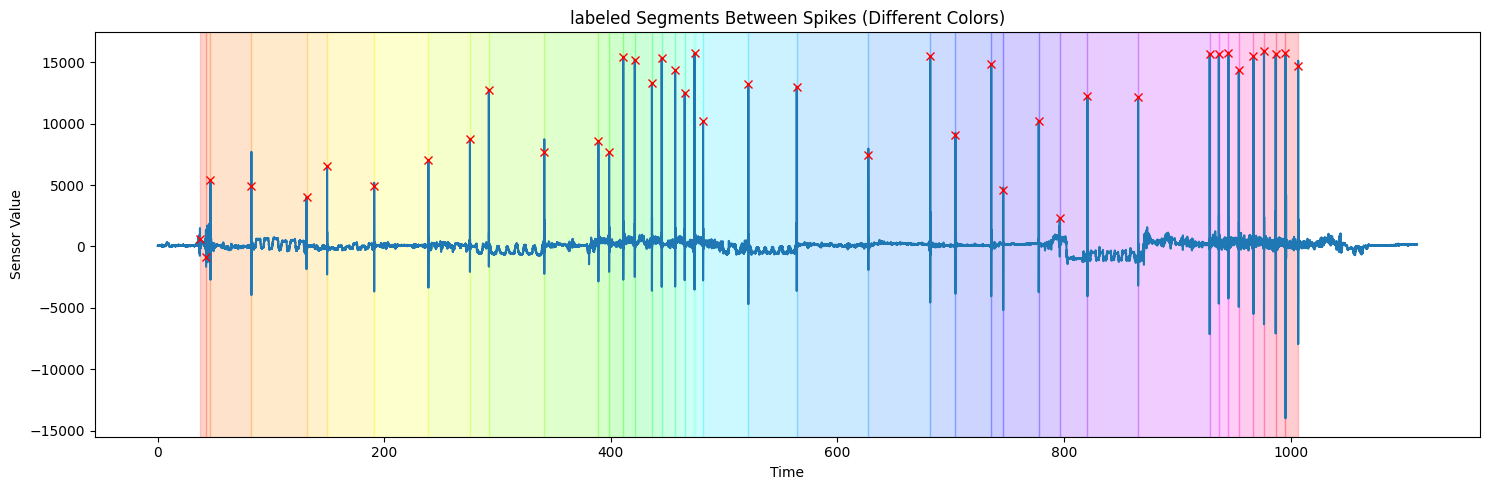

In [5]:
peak_df, peaks = detect_spikes(fixed_time_larm)
init_label_df = init_label(peak_df, peaks, fixed_time_larm)
plot_signal_peaks(init_label_df, peaks) 

Take a look at the generated plot. See that it makes sense wrt. the number of repetitions and peaks. Sometimes some peaks will have to be filtered away. Do so below and label again if necessary. 

Note that all the cells below must be run regardless of filtering away peaks or not.


### Activity -> correct label map
Can be altered to account for irregularities in the activity set. For instance if one extra push/pull rep is done...

In [6]:
# define rename map
# Below is the old map used for specialization project / by Maria
# rename_map = {
#     "Activity_2": "hand_up_back",
#     "Activity_4": "hands_forward",
#     "Activity_6": "hands_up",
#     "Activity_8": "push_1",
#     "Activity_9": "pull_1",
#     "Activity_10": "push_2",
#     "Activity_11": "pull_2",
#     "Activity_12": "push_3",
#     "Activity_13": "pull_3",
#     "Activity_14": "push_4",
#     "Activity_15": "pull_4",
#     "Activity_16": "push_5",
#     "Activity_17": "pull_5",
#     "Activity_19": "squatting", 
#     "Activity_21": "lifting",
#     "Activity_23": "sitting",
#     "Activity_25": "standing",
#     "Activity_27": "walking",
# }

# Rename map for preliminary data collection for M.Sc. spring 2026
rename_map = {
    "Activity_2" : "forward_lean",
    "Activity_4" : "sideways_lean",
    "Activity_6" : "torso_twist",
    "Activity_8" : "backward_lean",
    "Activity_10" : "drag_1",
    "Activity_12" : "drag_2",
    "Activity_14" : "drag_3",
    "Activity_16" : "drag_4",
    "Activity_18" : "drag_5",
    "Activity_20" : "arms_forward",
    "Activity_22" : "shoulder_load",
    "Activity_24" : "neutral_load_left",
    "Activity_26" : "neutral_load_right",
    "Activity_28" : "lying_arms_up",
    "Activity_30" : "stairs_up_1",
    "Activity_31" : "stairs_down_1",
    "Activity_32" : "stairs_up_2",
    "Activity_33" : "stairs_down_2",
    "Activity_34" : "stairs_up_3",
    "Activity_35" : "stairs_down_3",
    "Activity_36" : "stairs_up_4",
    "Activity_37" : "stairs_down_4",
    "Activity_38" : "stairs_up_5",
    "Activity_39" : "stairs_down_5",   
}

In [7]:
print(peaks)

[ 29760  34104  37219  66143 105064 119585 152855 191134 220466 233817
 272983 311185 318759 328745 336871 348969 355878 365389 372120 379053
 385104 417070 451228 501819 545515 563325 588604 597081 622117 636988
 656537 692334 742852 749310 756111 763410 773788 781213 789463 796387
 805374]


In [8]:
init_label_df

,Timestamp,Gyr.X,Gyr.Y,Gyr.Z,Axl.X,Axl.Y,Axl.Z,Hdr.X,Hdr.Y,Hdr.Z,Mag.X,Mag.Y,Mag.Z,ReconstructedTime,acc_mag,label
0,1770327860165,-1.330,7.315,1.680,39.040,857.90400,62.46400,43.840420,-626.04120,177.55370,-3038,882,24010,0.00000,861.060478,idle
1,1770327860166,-19.810,60.620,-7.000,53.680,1009.67200,76.12800,46.470844,-640.07010,174.92328,1176,1372,-2940,0.00125,1013.959843,idle
2,1770327860167,-7.455,48.335,10.955,63.928,1009.67200,83.44800,46.470844,-630.42523,177.11530,784,1372,-3038,0.00250,1015.129502,idle
3,1770327860168,-7.525,14.140,2.625,55.144,1011.62400,82.47200,47.347652,-622.53400,177.11530,294,1960,-2940,0.00375,1016.477058,idle
4,1770327860169,5.845,5.390,3.570,67.832,1009.18400,81.98400,39.456380,-635.68610,178.86891,294,1764,-3724,0.00500,1014.778253,idle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889295,1770328971979,-0.665,-0.035,-0.735,183.976,928.17600,326.47202,-181.499340,-720.73650,205.61157,1862,1666,-1764,1111.61875,1000.970447,idle
889296,1770328971979,-0.630,-0.070,-0.700,182.024,931.10400,320.12800,-175.361680,-716.35250,195.52827,784,1078,-1960,1111.62000,1001.283842,idle
889297,1770328971981,-0.560,-0.035,-0.805,185.440,925.73600,325.00800,-174.484880,-712.84520,195.52827,1274,1372,-2058,1111.62125,998.501545,idle
889298,1770328971982,-0.525,-0.070,-0.700,187.392,926.71204,327.44800,-172.731260,-718.98290,190.70583,1470,980,-1470,1111.62250,1000.566419,idle


dropping peak num 0
dropping peak num 1
dropping peak num 29
Excepted 'Activity_1'
Excepted 'Activity_3'
Excepted 'Activity_5'
Excepted 'Activity_7'
Excepted 'Activity_9'
Excepted 'Activity_11'
Excepted 'Activity_13'
Excepted 'Activity_15'
Excepted 'Activity_17'
Excepted 'Activity_19'
Excepted 'Activity_21'
Excepted 'Activity_23'
Excepted 'Activity_25'
Excepted 'Activity_27'
Excepted 'Activity_29'
{'label': 'idle', 'Start Time (s)': '46.52375', 'End Time (s)': '82.67875000000001'}
{'label': 'forward_lean', 'Start Time (s)': '82.67875000000001', 'End Time (s)': '131.33'}
{'label': 'idle', 'Start Time (s)': '131.33', 'End Time (s)': '149.48125000000002'}
{'label': 'sideways_lean', 'Start Time (s)': '149.48125000000002', 'End Time (s)': '191.06875'}
{'label': 'idle', 'Start Time (s)': '191.06875', 'End Time (s)': '238.9175'}
{'label': 'torso_twist', 'Start Time (s)': '238.9175', 'End Time (s)': '275.5825'}
{'label': 'idle', 'Start Time (s)': '275.5825', 'End Time (s)': '292.27125'}
{'labe

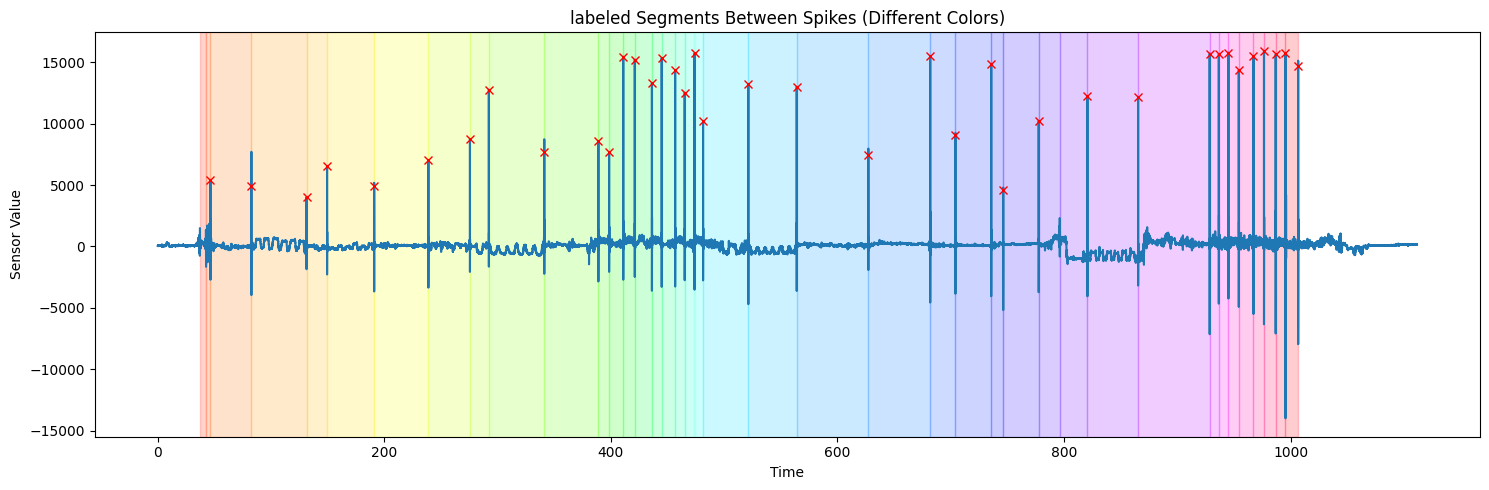

,Timestamp,Gyr.X,Gyr.Y,Gyr.Z,Axl.X,Axl.Y,Axl.Z,Hdr.X,Hdr.Y,Hdr.Z,Mag.X,Mag.Y,Mag.Z,ReconstructedTime,acc_mag,label,rep_id
0,1770327860165,-1.330,7.315,1.680,39.040,857.904,62.464,43.840420,-626.04120,177.55370,-3038,882,24010,0.00000,861.060478,idle,idle
1,1770327860166,-19.810,60.620,-7.000,53.680,1009.672,76.128,46.470844,-640.07010,174.92328,1176,1372,-2940,0.00125,1013.959843,idle,idle
2,1770327860167,-7.455,48.335,10.955,63.928,1009.672,83.448,46.470844,-630.42523,177.11530,784,1372,-3038,0.00250,1015.129502,idle,idle
3,1770327860168,-7.525,14.140,2.625,55.144,1011.624,82.472,47.347652,-622.53400,177.11530,294,1960,-2940,0.00375,1016.477058,idle,idle
4,1770327860169,5.845,5.390,3.570,67.832,1009.184,81.984,39.456380,-635.68610,178.86891,294,1764,-3724,0.00500,1014.778253,idle,idle


In [9]:


add_peak =  142881  + 60*800

#manually_filtered_peaks = peaks
# if no peaks need be removed, otherwise:

# code for adding a peak where none was detected
manually_filtered_peaks = []
#manually_filtered_peaks = [] # potentially manually select which peaks to keep here
drop_peaks = [0, 1, 29] # define which peaks to drop here (0 indexed indices)

for i in range(0, len(peaks)):
    peak = peaks[i]
    # if peak == 142881:
    #     manually_filtered_peaks.append(peak)
    #     print("adding the extra peak behind", peak)
    #     manually_filtered_peaks.append(add_peak)
    
    if i in drop_peaks:
        print(f"dropping peak num {i}")
        continue
    else:
        manually_filtered_peaks.append(peaks[i])



rows = []
push_idx = 1
pull_idx = 1
for i in range(len(manually_filtered_peaks) - 1):
    start_t = float(init_label_df["ReconstructedTime"].iloc[manually_filtered_peaks[i]]) 
    end_t   = float(init_label_df["ReconstructedTime"].iloc[manually_filtered_peaks[i+1]])
    # also add a 'rep_id' column to df
    init_label_df["rep_id"] = "idle"  
    try:
        if 'push' in rename_map[f"Activity_{i+1}"]:
            label = rename_map[f"Activity_{i+1}"]
            push_idx += 1
            start_t = start_t + 0.5 # filter away spikes at the beginning of push pull segments
            
        elif 'pull' in rename_map[f"Activity_{i+1}"]:
            label = rename_map[f"Activity_{i+1}"]
            pull_idx += 1
            start_t = start_t + 0.5
        else:
            # Automatically transfer labels into the rep_id column. Making already segmented activities (push, pull, drag, stairs) finished wrt. their rep ids.
            label = rename_map[f"Activity_{i+1}"]
    except Exception as e:
        print("Excepted", e)
        label = "idle"
    rows.append({
        "label": label,
        "Start Time (s)": str(start_t),
        "End Time (s)": str(end_t)
    })
    

# Sanity check: see if start stop times for each label is correct. Compare plot x-axis with the printed start stop times.
for item in rows:
    print(item)
plot_signal_peaks(init_label_df, manually_filtered_peaks)

init_label_df.head()

If everything looks good, proceed to concatenate and save...


In [10]:
start_stop_df = pd.DataFrame(rows)

# Drop idle rows
start_stop_df = start_stop_df.drop(start_stop_df[start_stop_df['label'] == 'idle'].index)

start_stop_df.to_csv(output_dir / "start_stop_labels.csv")

# label both arm and back files
_, labeled_larm_path = apply_corrected_labels(new_time_file=fixed_time_larm, start_stop_csv_path=output_dir / "start_stop_labels.csv")
_, labeled_rarm_path = apply_corrected_labels(new_time_file=fixed_time_rarm, start_stop_csv_path=output_dir / "start_stop_labels.csv")
_, labeled_lb_path = apply_corrected_labels(new_time_file=fixed_time_lb, start_stop_csv_path=output_dir / "start_stop_labels.csv")
_, labeled_ub_path = apply_corrected_labels(new_time_file=fixed_time_ub, start_stop_csv_path=output_dir / "start_stop_labels.csv")

In [11]:
start_stop_df

,label,Start Time (s),End Time (s)
1,forward_lean,82.67875000000001,131.33
3,sideways_lean,149.48125000000002,191.06875
5,torso_twist,238.9175,275.5825
7,backward_lean,292.27125,341.22875
9,drag_1,388.98125,398.44875
11,drag_2,410.93125,421.08875
13,drag_3,436.21125,444.8475
15,drag_4,456.73625,465.15
17,drag_5,473.81625,481.38
19,arms_forward,521.3375,564.035


### Label Mitch data
(Also includes dropping end duplicates and adding ReconstructedTime)


Basically the exact same as Maria's run_label_mitch.py file.

read filepath: C:\Users\Bruker\Data_msc26_prelim\prelim_1\mitch_B0308-LEFT.txt
output path C:\Users\Bruker\Data_msc26_prelim\prelim_1\mitch_B0308-LEFT_del_end_dupli.csv
read filepath: C:\Users\Bruker\Data_msc26_prelim\prelim_1\mitch_B0510-RIGHT.txt
output path C:\Users\Bruker\Data_msc26_prelim\prelim_1\mitch_B0510-RIGHT_del_end_dupli.csv
113913
114016


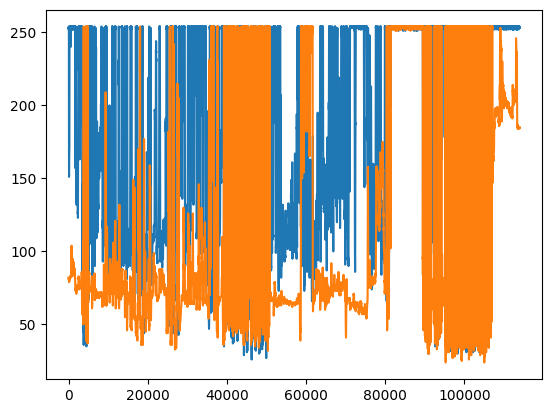

In [12]:
df_dupli_left, outpath_dupli_left = remove_end_duplicates(str(raw_lsole))
df_dupli_right, outpath_dupli_right = remove_end_duplicates(str(raw_rsole))

print(len(df_dupli_left))
print(len(df_dupli_right))

df_dupli_right = df_dupli_right[:len(df_dupli_left)]

plt.plot(df_dupli_right['Fsr.01'])
plt.plot(df_dupli_left['Fsr.01'])

In [13]:
# df_dupli_left, outpath_dupli_left = remove_end_duplicates(raw_left_path)
# df_dupli_right, outpath_dupli_right = remove_end_duplicates(raw_right_path)


df_time_left, outpath_time_left = add_ReconstructedTime(outpath_dupli_left, df_dupli_left)
df_time_right, outpath_time_right = add_ReconstructedTime(outpath_dupli_right, df_dupli_right)

df_time_left['ReconstructedTime'] = df_time_right['ReconstructedTime']

df_label_left, outpath_label_left = apply_corrected_labels(outpath_time_left, output_dir / "start_stop_labels.csv", df_time_left)
df_label_right, outpath_label_right = apply_corrected_labels(outpath_time_right, output_dir / "start_stop_labels.csv", df_time_right)

df_fsr_left, outpath_fsr_left = extract_pressure_data(outpath_label_left, df_label_left)
df_fsr_right, outpath_fsr_right = extract_pressure_data(outpath_label_right, df_label_right)

Sample number: 113913
Recorded time sec: 1112.031
Recorded time min: 18.53385
Sample number: 113913
Recorded time sec: 1112.031
Recorded time min: 18.53385


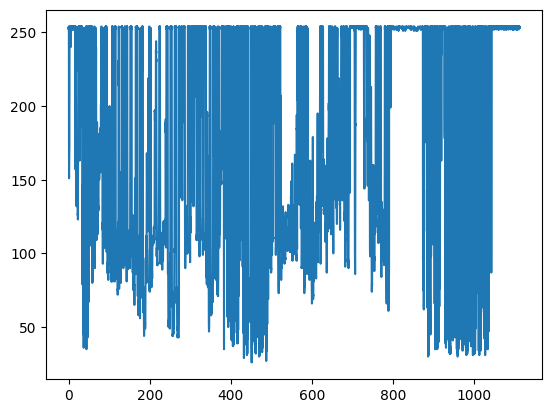

right reconstr. time length 113913
left reconstr. time length 113913


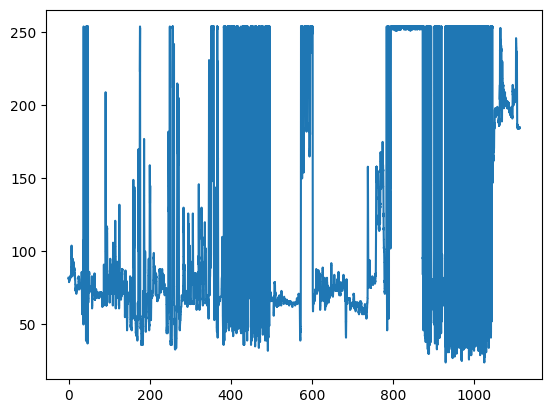

In [14]:


#df_fsr_right['ReconstructedTime'] = df_fsr_left['ReconstructedTime'][:len(df_fsr_right)]
plt.plot(df_fsr_right['ReconstructedTime'], df_fsr_right['Fsr.01'])
plt.show()



#df_fsr_left['ReconstructedTime'] = df_fsr_right['ReconstructedTime']

plt.plot(df_fsr_left['ReconstructedTime'], df_fsr_left['Fsr.01'])


print("right reconstr. time length", len(df_fsr_right['ReconstructedTime']))
print("left reconstr. time length", len(df_fsr_left['ReconstructedTime']))

### Drop idle for all sensors

In [15]:
df_left_no_idle, outpath_lsole_no_idle = remove_idle(correct_label_filepath=outpath_label_left, correct_label_df=df_label_left)
df_right_no_idle, outpath_rsole_no_idle = remove_idle(correct_label_filepath=outpath_label_right, correct_label_df=df_label_right)
df_rarm_no_idle, outpath_rarm_no_idle = remove_idle(correct_label_filepath=labeled_rarm_path)
df_larm_no_idle, outpath_larm_no_idle = remove_idle(correct_label_filepath=labeled_larm_path)
df_lb_no_idle, outpath_lb_no_idle = remove_idle(correct_label_filepath=labeled_lb_path)
df_ub_no_idle, outpath_ub_no_idle = remove_idle(correct_label_filepath=labeled_ub_path)

### Apply median filter for all sensors and drop IMU columns from Mitch files

Kernel sizes: 21 for Muse sensors, 9 for mitch. Reasoning found in Maria's master's thesis, where different kernel sizes were tested.

In [16]:
imu_columns = ["Axl.X", "Axl.Y", "Axl.Z",
               "Gyr.X", "Gyr.Y", "Gyr.Z",
               "Mag.X", "Mag.Y", "Mag.Z"]

fsr_columns = [f"Fsr.{str(sensor).zfill(2)}" for sensor in range(1, 17)]

df_filtered_rarm, path_rarm_filtered = median_filter_medfilt(outpath_rarm_no_idle, imu_columns, kernel_size=21)
df_filtered_larm, path_back_larm = median_filter_medfilt(outpath_larm_no_idle, imu_columns, kernel_size=21)
df_filtered_lb, path_lb_filtered = median_filter_medfilt(outpath_lb_no_idle, imu_columns, kernel_size=21)
df_filtered_ub, path_back_ub = median_filter_medfilt(outpath_ub_no_idle, imu_columns, kernel_size=21)

df_filtered_lsole, path_lsole_filtered = median_filter_medfilt(outpath_lsole_no_idle, fsr_columns, kernel_size=9)
df_filtered_rsole, path_rsole_filtered = median_filter_medfilt(outpath_rsole_no_idle, fsr_columns, kernel_size=9)

df_filtered_lsole = df_filtered_lsole.drop(columns=imu_columns)
df_filtered_rsole = df_filtered_rsole.drop(columns=imu_columns)

df_filtered_lsole.to_csv(f"{path_lsole_filtered.rstrip('.csv')}_drop_imu.csv")
df_filtered_rsole.to_csv(f"{path_rsole_filtered.rstrip('.csv')}_drop_imu.csv")


### Find repetition IDs


##### Sanity check: same start, stop times in all reconstructed times?

In [17]:
dfs = [df_filtered_rarm, df_filtered_larm, df_filtered_lsole, df_filtered_rsole, df_filtered_lb, df_filtered_ub]

for df in dfs:
    RT_list = df['ReconstructedTime'].to_list()
    print("Start time", RT_list[0])
    print("Stop time", RT_list[-1])
    print("--------------------------")

Start time 82.67875000000001
Stop time 1006.71875
--------------------------
Start time 82.67875000000001
Stop time 1006.71875
--------------------------
Start time 82.68577998806096
Stop time 1006.7262173871056
--------------------------
Start time 82.68577998806096
Stop time 1006.7262173871056
--------------------------
Start time 82.67875000000001
Stop time 1006.71875
--------------------------
Start time 82.67875000000001
Stop time 1006.71875
--------------------------


#### Rep id methodology:
- Extract windows of single activities
- Treat each activity one by one
- Use accel magnitude of the most relevant sensor e.g. left arm for left arm movement, lower back for back centered movements etc.
- Split so that both transients of a rep is contained within the rep.

More details in specialization project report. Alternate method in Maria's thesis.

#### Switch the activity_label argument to the desired one below and run through


Local: [    5 38874]
Original: RangeIndex(start=101534, stop=179272, step=38869)


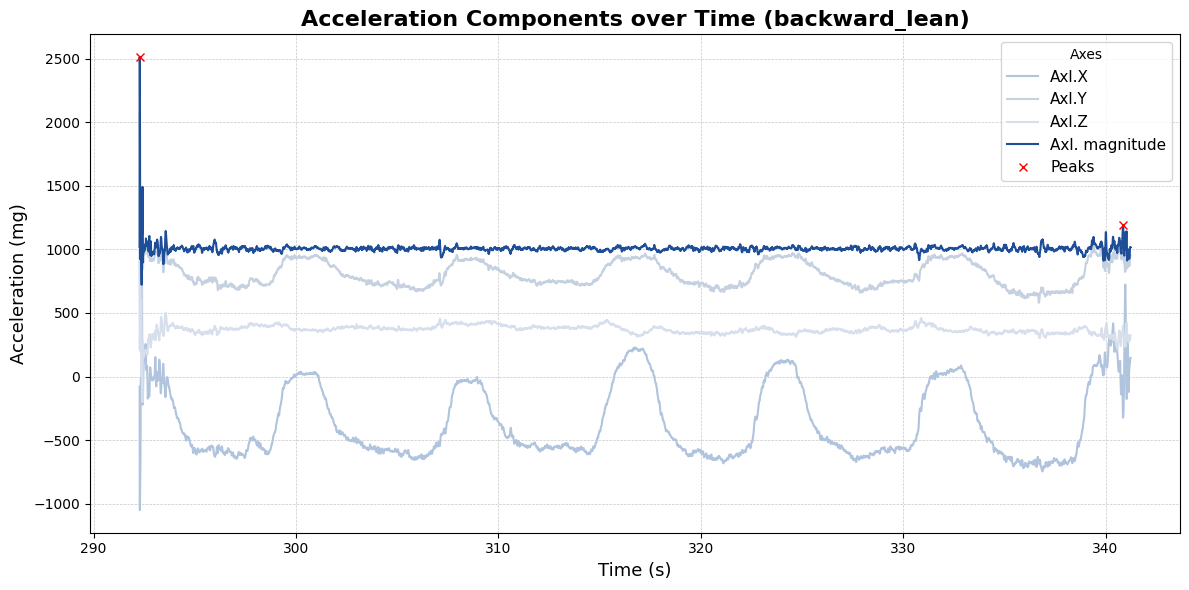

In [24]:
# we use the arm df from the previous cell
activity_label = 'backward_lean'
_, peaks, peaks_mask = plot_activity_accelerations_peaks_and_magnitude(df_filtered_lb, activity_label, height=1000, distance=900)

In [ ]:
# investigate the peaks
peaks

In [29]:
# Manually alter the peaks such that the peaks can be used to differentiate between 
drop_peaks = []
filtered_peaks = []
filtered_peaks_original = []
for i in range(len(peaks_mask)):
    
    if i not in drop_peaks:
        filtered_peaks.append(peaks_mask[i])
        filtered_peaks_original.append(peaks[i])
        
    if i == 0:
        filtered_peaks.append(peaks_mask[i] + 2*800)
        filtered_peaks_original.append(peaks[i]+ 2*800)
        
        filtered_peaks.append(peaks_mask[i] + 6*800)
        filtered_peaks_original.append(peaks[i]+ 6*800)

        filtered_peaks.append(peaks_mask[i] + 10*800)
        filtered_peaks_original.append(peaks[i]+ 10*800)
        filtered_peaks.append(peaks_mask[i] + 14*800)
        filtered_peaks_original.append(peaks[i]+ 14*800)
        filtered_peaks.append(peaks_mask[i] + 18*800)
        filtered_peaks_original.append(peaks[i]+ 18*800)
        
        filtered_peaks.append(peaks_mask[i] + 22*800)
        filtered_peaks_original.append(peaks[i]+ 22*800)
        
        filtered_peaks.append(peaks_mask[i] + 26*800)
        filtered_peaks_original.append(peaks[i]+ 26*800)
        filtered_peaks.append(peaks_mask[i] + 30*800)
        filtered_peaks_original.append(peaks[i]+ 30*800)
        filtered_peaks.append(peaks_mask[i] + 34*800)
        filtered_peaks_original.append(peaks[i]+ 34*800)
        filtered_peaks.append(peaks_mask[i] + 38*800)
        filtered_peaks_original.append(peaks[i]+ 38*800)
        filtered_peaks.append(peaks_mask[i] + 42*800)
        filtered_peaks_original.append(peaks[i]+ 42*800)     
        filtered_peaks.append(peaks_mask[i] + 46*800)
        filtered_peaks_original.append(peaks[i]+ 46*800)   


In [ ]:
filtered_peaks_original

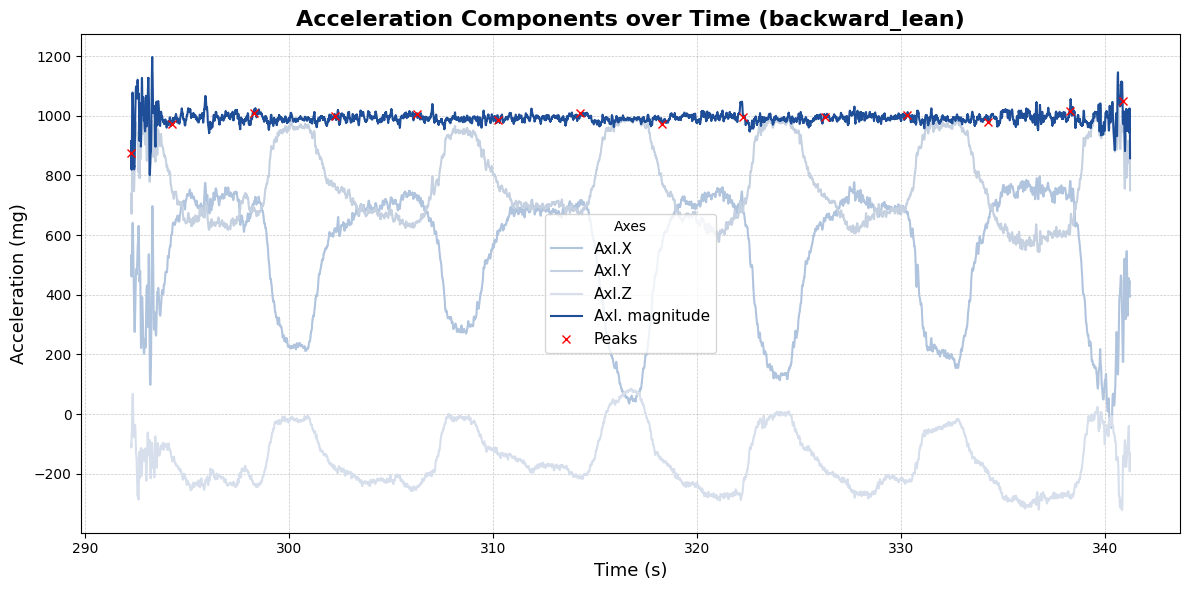

(            Timestamp   Gyr.X   Gyr.Y   Gyr.Z      Axl.X      Axl.Y  \
 101529  1581502604395   8.925  18.690  -9.450  531.43200  737.85600   
 101530  1581502604395   9.660  18.690  -9.975  520.69600  731.51200   
 101531  1581502604397  10.045  18.690 -10.465  515.81600  728.58400   
 101532  1581502604398  10.745  18.690 -10.850  507.52002  726.14400   
 101533  1581502604399  11.025  18.690 -11.270  499.22400  713.45600   
 ...               ...     ...     ...     ...        ...        ...   
 140692  1581502653356  -2.415  10.815  -7.665  393.81600  809.10400   
 140693  1581502653358  -2.415  10.815  -8.120  393.81600  794.95200   
 140694  1581502653359  -2.415  10.815  -8.540  393.81600  782.26404   
 140695  1581502653360  -2.415  10.115  -8.715  393.81600  771.04004   
 140696  1581502653361  -2.415   9.310  -8.925  393.81600  750.05600   
 
             Axl.Z      Hdr.X      Hdr.Y       Hdr.Z  Mag.X  Mag.Y  Mag.Z  \
 101529 -102.48000 -368.25952 -457.69400   80.666374   13

In [30]:
# plot again to see that everything aligns

plot_activity_accelerations_peaks_and_magnitude(df_filtered_rarm, activity_label, peak_indices=filtered_peaks)

In [31]:
len(filtered_peaks) == len(filtered_peaks_original)


True

In [32]:
# Split in the middle between last and first peak
even = []
odd = []
even_orig = []
odd_orig = []
for i in range(len(filtered_peaks)):
    if i % 2 == 0:
        # print(f'adding index {i} to EVEN')
        # print('second mark is', df_filtered_back['ReconstructedTime'].iloc[int(filtered_peaks_original[i])])
        even.append(filtered_peaks[i])
        even_orig.append(filtered_peaks_original[i])
    else:
        # print(f'adding index {i} to ODD')
        # print('second mark is', df_filtered_back['ReconstructedTime'].iloc[int(filtered_peaks_original[i])])
        odd.append(filtered_peaks[i])
        odd_orig.append(filtered_peaks_original[i])

print(even_orig)
print(odd_orig)
filtered_peaks_original = [] # clear the list
for i in range(len(odd_orig)):
    first = even_orig[i]
    second = odd_orig[i]
    # print(first,second)
    # print("In time")
    # print(df_filtered_back['ReconstructedTime'].iloc[int(first)], df_filtered_back['ReconstructedTime'].iloc[int(second)],)
    print((first + second) // 2)
    # segment at middle point between even and odd peak, i.e. last of prev rep and first of next rep:
    
    filtered_peaks_original.append((first + second) // 2) 

print("Splits seconds marks")
for idx in filtered_peaks_original:
    print(df_filtered_lb['ReconstructedTime'].iloc[int(idx)])   
    
    

[101534, 106334, 112734, 119134, 125534, 131934, 138334]
[103134, 109534, 115934, 122334, 128734, 135134, 140403]
102334
107934
114334
120734
127134
133534
139368
Splits seconds marks
293.27750000000003
300.27750000000003
308.27750000000003
316.27750000000003
324.27750000000003
332.27750000000003
339.57


#### Save the repetitions start stop times to a .csv-file
Below, the df is also visualized. Check that the timestamps correspond with the plot above:)

In [33]:
print(filtered_peaks_original)
import importlib
import pre_processing.segment_repetition_vol2 as seg
importlib.reload(seg)
from pre_processing.segment_repetition_vol2 import get_start_stop_times_from_peaks

start_stop_reps_dict, start_stop_reps_df = get_start_stop_times_from_peaks(df_filtered_lb, filtered_peaks_original, activity_label, num_reps=6, L_R_alternate=True)
start_stop_reps_df.to_csv(output_dir / f'start_stop_rep_times_{activity_label}.csv')


[102334, 107934, 114334, 120734, 127134, 133534, 139368]


In [34]:
# check that df makes sense
start_stop_reps_df

,rep_id,start_time,stop_time
0,backward_lean_left_1,293.2775,300.2775
1,backward_lean_right_2,300.2775,308.2775
2,backward_lean_left_3,308.2775,316.2775
3,backward_lean_right_4,316.2775,324.2775
4,backward_lean_left_5,324.2775,332.2775
5,backward_lean_right_6,332.2775,339.5700


#### Now, add a rep_id column to each sensor dataframe based on start stop time .csv files


In [35]:
# defien a dict with all dfs to assign rep_id for, they must have a corresponding .csv file with start_stop_times for the relevant activities. 
filtered_dfs = {
    "left_arm" : df_filtered_larm,
    "right_arm" : df_filtered_rarm,
    "upper_back" : df_filtered_ub,
    "lower_back" : df_filtered_lb,
    "left_sole" : df_filtered_lsole,
    "right_sole" : df_filtered_rsole
    }

# define a set of labels that if they occur, should not have rep_id assigned from a .csv, but rather from their label which is assumed to already be numbered after repetitions. 
numbered_labels = {
        "push",
        "pull",
        "drag",
        "stairs_up",
        "stairs_down"
    }
# add a rep_id columm (just a copy of the labels to each df.)
for _, df in filtered_dfs.items():
    df["rep_id"] = df["label"].copy()
    
# run the next cell to assign rep_ids and save the final .csv files. 

In [36]:
import pre_processing.segment_repetition_vol2 as seg
import importlib
importlib.reload(seg)
from pre_processing.segment_repetition_vol2 import assign_rep_ids

assign_rep_ids(sensor_dfs=filtered_dfs, output_dir=output_dir, numbered_labels=numbered_labels)

Activities: ['forward_lean', 'sideways_lean', 'torso_twist', 'backward_lean', 'drag', 'arms_forward', 'shoulder_load', 'neutral_load_left', 'neutral_load_right', 'lying_arms_up', 'stairs_up', 'stairs_down']
✅ Assigned rep_ids for forward_lean
✅ Assigned rep_ids for sideways_lean
✅ Assigned rep_ids for torso_twist
✅ Assigned rep_ids for backward_lean
✅ Normalized activity labels for movement 'drag', rep_id column has not been altered (expected).
✅ Assigned rep_ids for arms_forward
✅ Assigned rep_ids for shoulder_load
⚠️ WARNING: Missing CSV for activity 'neutral_load_left', skipping
⚠️ WARNING: Missing CSV for activity 'neutral_load_right', skipping
✅ Assigned rep_ids for lying_arms_up
✅ Normalized activity labels for movement 'stairs_up', rep_id column has not been altered (expected).
✅ Normalized activity labels for movement 'stairs_down', rep_id column has not been altered (expected).
💾 Saved: C:\Users\Bruker\Data_msc26_prelim\prelim_1\left_arm_with_rep_ids.csv
💾 Saved: C:\Users\Bruk

{'left_arm':             Timestamp   Gyr.X   Gyr.Y  Gyr.Z    Axl.X    Axl.Y     Axl.Z  \
 0       1770327942857   0.000   0.000  0.000    0.000    0.000     0.000   
 1       1770327942859   0.000   0.000  0.000    0.000    0.000     0.000   
 2       1770327942860   0.000   0.000  0.000    0.000    0.000     0.000   
 3       1770327942861   0.000   0.000  0.000    0.000   32.208   575.352   
 4       1770327942863 -42.910  45.745  0.000    0.000  199.104  1605.032   
 ...               ...     ...     ...    ...      ...      ...       ...   
 402593  1770328867055  -7.280 -13.930 -6.265  269.864  991.616   169.336   
 402594  1770328867056  -7.280 -13.860 -6.055  269.864  991.616   169.336   
 402595  1770328867058  -7.280 -13.335 -5.950  269.864    0.000     0.000   
 402596  1770328867059  -7.105 -12.670 -5.705  269.864    0.000     0.000   
 402597  1770328867060  -6.860   0.000 -2.870  268.888    0.000     0.000   
 
              Hdr.X      Hdr.Y      Hdr.Z  Mag.X  Mag.Y  Mag.Z

## Finished! 🎉
Go over output directory and delete unnecessary temp .csv files. DO NOT INGORE THIS STEP UNLESS YOU WANT TO DELETE THE SIMS OFF YOUR COMPUTER TO MAKE ROOM FOR DATA FILES (hint: you don't want that).


## What to do next? 💕
Add the correct paths to the get_paths.py - file (both individual test file paths and test folder path!). Then run pre_processing.clean_dataset_columns for the current test file. Requires  get_paths to be correct. after cleaning, add the _cleaned.csv suffix, i.e. the new path to get_paths. 

-----> Once all of the above has been completed, move on to **feature extraction**